# Imports

In [13]:
from pathlib import Path
import math
import os
import sys

import torch
from torchvision.datasets import VisionDataset, MNIST, EMNIST
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders

PROJECT_ROOT = Path(os.path.abspath(os.pardir))
sys.path.append(str(PROJECT_ROOT))

from models.lenet import Net as LeNet
from config import Config, load_config

In [3]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

mnist_config = load_config(str(PROJECT_ROOT / "configs" / "mnist" / "lenet_baseline.yaml"))

# Model
mnist_model = LeNet(
    prior_sigma1=mnist_config.prior.sigma1,
    prior_sigma2=mnist_config.prior.sigma2,
    prior_pi=mnist_config.prior.pi,
    num_classes=mnist_config.model.num_classes,
    rho_init=mnist_config.model.rho_init,
).to(device)

# emnist_model = LeNet(
#     prior_sigma1=math.exp(-0.8470609173270909),
#     prior_sigma2=math.exp(-7.293222293379696),
#     prior_pi=0.44622172885322486,
#     num_classes=26,
#     rho_init=-5.724956071835678
# ).to(device)

load_checkpoint(
    path=str(PROJECT_ROOT / "runs" / "20260917_124439_lenet_mnist_baseline" / "checkpoints" / "last.pt"),
    model=mnist_model,
    device=device
)

# config.model_name = 'lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1'
# load_checkpoint(emnist_model, None, f'{config.checkpoint_path}/{config.model_name}/{config.model_name}_20260317.pth', device)

Checkpoint loaded from /home/qosquo/Git/bayes_nn/runs/20260917_124439_lenet_mnist_baseline/checkpoints/last.pt at epoch 99.


{'epoch': 99,
 'model_state_dict': OrderedDict([('conv1.mu',
               tensor([[[[-0.0226, -0.2455, -0.1579, -0.1291, -0.1996],
                         [-0.3444, -0.0863, -0.0532, -0.0349, -0.1644],
                         [-0.3383,  0.0793, -0.1358,  0.1744, -0.2362],
                         [ 0.0642,  0.0870,  0.3555,  0.1363,  0.3200],
                         [ 0.3864,  0.4423,  0.2830,  0.3166,  0.4468]]],
               
               
                       [[[ 0.3273,  0.1350, -0.0900, -0.3102, -0.2776],
                         [ 0.1698,  0.0482, -0.1434, -0.3156, -0.0301],
                         [ 0.0379,  0.2857,  0.2211,  0.1497, -0.0014],
                         [ 0.0137,  0.1134,  0.4264,  0.2111,  0.2337],
                         [-0.2277, -0.1030, -0.0080,  0.1201,  0.1667]]],
               
               
                       [[[ 0.0387,  0.0970, -0.2267, -0.3673, -0.1898],
                         [ 0.2250, -0.1946, -0.3825, -0.2843,  0.0640],
       

# Preliminary functions

In [6]:
from typing import Callable
from torch.utils.data import DataLoader


def get_loader(dataset: Callable[..., VisionDataset], dataset_kwargs: dict | None, ks: int) \
        -> tuple[DataLoader, DataLoader, DataLoader]:
    return get_dataloaders(
        data_dir=str(PROJECT_ROOT / "data"),
        batch_size=14,
        num_workers=1,
        use_cuda=torch.cuda.is_available(),
        dataset=dataset,
        dataset_kwargs=dataset_kwargs,
        extra_transforms=[GaussianBlur(ks)],
)

In [7]:
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable, Any

from utils.uncertainty import mc_predict, quantify_uncertainties

def evaluate_with_blurs(
    model: torch.nn.Module,
    get_loader: Callable[[int], DataLoader],
    kernel_sizes: list[int],
    device: torch.device,
    mc_samples: int = 10,
    desc: str = "",
) -> dict[int, tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]]:
    """
    Returns dict with keys as kernel sizes and values as tuples of:
    (predictions, total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty)
    """
    res = {}

    pbar = tqdm(kernel_sizes, desc=desc)

    for ks in pbar:
        pbar.set_description(f"{desc} - Kernel {ks}")
        k_blur_preds, k_blur_tus, k_blur_aus, k_blur_eus = [], [], [], []
        loader = get_loader(ks)

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            mc_preds = mc_predict(model, x, mc_samples=mc_samples)
            tu, au, eu = quantify_uncertainties(mc_preds)
            k_blur_preds.append(mc_preds.mean(dim=0))
            k_blur_tus.append(tu)
            k_blur_aus.append(au)
            k_blur_eus.append(eu)

        k_blur_preds = torch.cat(k_blur_preds, dim=0)
        k_blur_tus = torch.cat(k_blur_tus, dim=0)
        k_blur_aus = torch.cat(k_blur_aus, dim=0)
        k_blur_eus = torch.cat(k_blur_eus, dim=0)

        res[ks] = (k_blur_preds, k_blur_tus, k_blur_aus, k_blur_eus)

    return res

In [9]:
def get_dataset_labels(dataset: Callable[..., VisionDataset]) -> torch.Tensor:
    loader = get_dataloaders(
        data_dir=str(PROJECT_ROOT / "data"),
        batch_size=14,
        num_workers=1,
        use_cuda=torch.cuda.is_available(),
        dataset=dataset,
        dataset_kwargs={"split": "letters"} if dataset == "EMNIST" else None,
    )[2]
    return torch.cat([y for _, y in loader]).to(device)

# Evaluation with Gaussian Blur

In [6]:
_d = np.load("npz/bcnn_vi_mnist_vs_emnist-letters_comparison.npz", allow_pickle=True)
T = _d["mc_samples"]
kernel_sizes = _d["kernel_sizes"]
mnist_evals = _d["mnist_evals"].item()
emnist_evals = _d["emnist_evals"].item()

In [10]:
T = 10
kernel_sizes = [1, 3, 5, 7, 9]

In [11]:
from torchvision.transforms.transforms import GaussianBlur
mnist_evals = evaluate_with_blurs(
    mnist_model,
    lambda ks: get_loader(torchvision.datasets.MNIST, None, ks)[2],
    kernel_sizes, device, T,
    desc="MNIST Gaussian Blur",
)

MNIST Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [04:03<00:00, 48.73s/it]


In [6]:
from torchvision.transforms.transforms import GaussianBlur
emnist_evals = evaluate_with_blurs(
    emnist_model,
    lambda ks: get_loader("EMNIST", {"split": "letters"}, ks)[2],
    kernel_sizes, device, T,
    desc="EMNIST Gaussian Blur",
)

EMNIST Gaussian Blur - Kernel 9: 100%|██████████| 5/5 [08:21<00:00, 100.23s/it]


In [8]:
np.savez(
    "npz/bcnn_vi_mnist_vs_emnist-letters_comparison.npz",
    kernel_sizes=kernel_sizes,
    mc_samples=T,
    mnist_evals=mnist_evals,
    emnist_evals=emnist_evals
)

# Метрики
## Вычисление точности


In [14]:
def calculate_accuracy(preds: torch.Tensor, labels: torch.Tensor) -> float:
    correct = (preds.argmax(dim=1) == labels).sum().item()
    total = labels.size(0)
    return correct / total

mnist_accuracies = [calculate_accuracy(mnist_evals[ks][0], get_dataset_labels(MNIST)) for ks in kernel_sizes]
# emnist_accuracies = [calculate_accuracy(emnist_evals[ks][0], get_dataset_labels(EMNIST)) for ks in kernel_sizes]


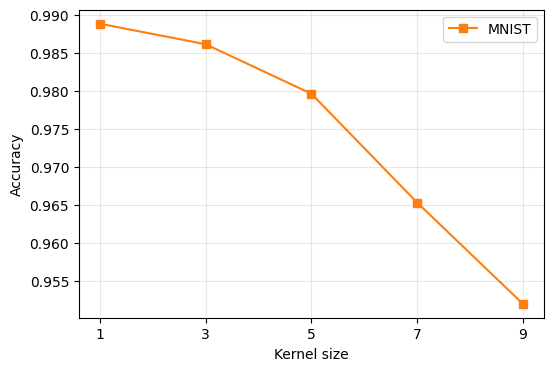

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {'E': 'C0', 'M': 'C1'}

# ax.plot(kernel_sizes, emnist_accuracies, color=colors['E'], label="EMNIST-letters", marker='o')
ax.plot(kernel_sizes, mnist_accuracies, color=colors['M'], label="MNIST", marker='s')

ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

## Вычисление неопределенности

In [18]:
mnist_total_unc = [mnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
mnist_alea_unc = [mnist_evals[ks][2].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
mnist_epis_unc = [mnist_evals[ks][3].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]

# emnist_total_unc = [emnist_evals[ks][1].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
# emnist_alea_unc = [emnist_evals[ks][2].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]
# emnist_epis_unc = [emnist_evals[ks][3].diagonal(dim1=1, dim2=2).sum(-1).mean().item() for ks in kernel_sizes]


/tmp/ipykernel_589132/2269688823.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


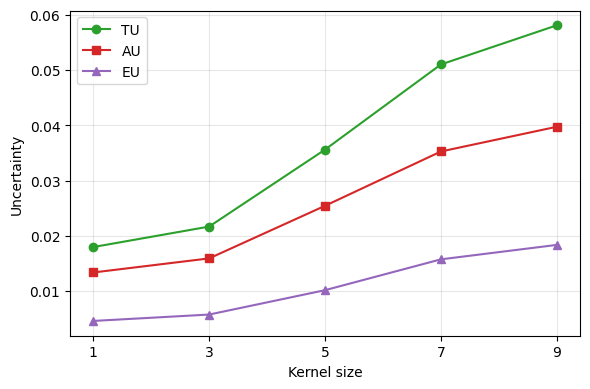

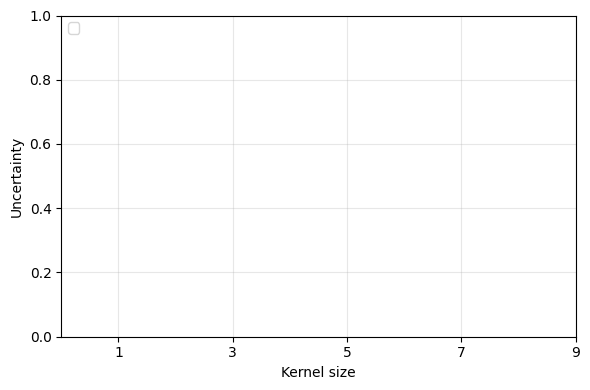

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {'TU': 'C2', 'AU': 'C3', 'EU': 'C4'}

# Левый subplot — MNIST
ax.plot(kernel_sizes, mnist_total_unc, label='TU', marker='o', color=colors['TU'])
ax.plot(kernel_sizes, mnist_alea_unc,  label='AU', marker='s', color=colors['AU'])
ax.plot(kernel_sizes, mnist_epis_unc,  label='EU', marker='^', color=colors['EU'])
# ax.set_title('MNIST')
ax.set_xlabel('Kernel size')
ax.set_ylabel('Uncertainty')
ax.set_xticks(kernel_sizes)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()

fig, ax = plt.subplots(figsize=(6, 4))

# Правый subplot — EMNIST-letters
# ax.plot(kernel_sizes, emnist_total_unc, label='TU', marker='o', color=colors['TU'])
# ax.plot(kernel_sizes, emnist_alea_unc,  label='AU', marker='s', color=colors['AU'])
# ax.plot(kernel_sizes, emnist_epis_unc,  label='EU', marker='^', color=colors['EU'])
# ax.set_title('EMNIST-digits')
ax.set_xlabel('Kernel size')
ax.set_ylabel('Uncertainty')
ax.set_xticks(kernel_sizes)
ax.grid(True, alpha=0.3)
# ax.set_ylim(top=0.07)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()



# Корреляция между предсказанной уверенностью и неопределенностью

In [20]:
import numpy as np

def calculate_correlations(probs: torch.Tensor, total_uncs: torch.Tensor, labels: torch.Tensor) -> tuple[float, float]:
    pred_conf = probs[torch.arange(len(probs)), probs.argmax(dim=1)].cpu().numpy()
    true_conf = probs[torch.arange(len(labels)), labels].cpu().numpy()
    total_uncs = total_uncs.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy()
    return np.corrcoef(pred_conf, total_uncs)[0, 1], np.corrcoef(true_conf, total_uncs)[0, 1]

mnist_correlations_pred = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1], get_dataset_labels(MNIST))[0] for ks in kernel_sizes]
mnist_correlations_true = [calculate_correlations(mnist_evals[ks][0], mnist_evals[ks][1], get_dataset_labels(MNIST))[1] for ks in kernel_sizes]

# emnist_correlations_pred = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1], get_dataset_labels("EMNIST"))[0] for ks in kernel_sizes]
# emnist_correlations_true = [calculate_correlations(emnist_evals[ks][0], emnist_evals[ks][1], get_dataset_labels("EMNIST"))[1] for ks in kernel_sizes]

# Левый subplot — pred_conf

NameError: name 'emnist_correlations_pred' is not defined

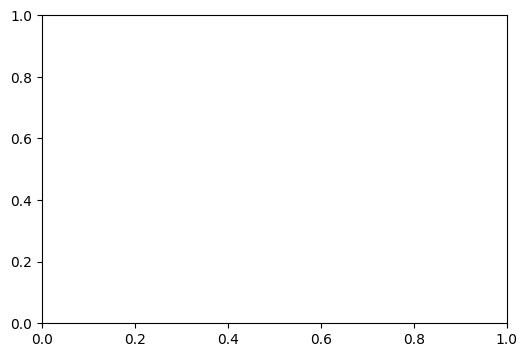

In [22]:
colors = {'E': 'C0', 'M': 'C1'}
markers = {'E': 'o', 'M': 's'}

fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

ax.plot(kernel_sizes, emnist_correlations_pred, marker=markers['E'], color=colors['E'], label='EMNIST-digits')
ax.plot(kernel_sizes, mnist_correlations_pred, marker=markers['M'], color=colors['M'], label='MNIST')
# ax.set_title('Predicted class')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-1,top=-0.65)
ax.legend()
plt.tight_layout()
plt.show()



# Правый subplot — true_conf


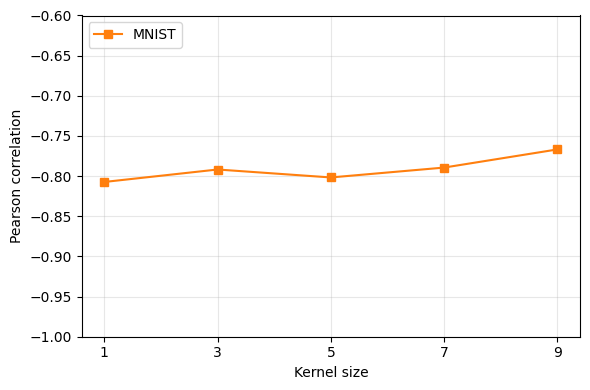

In [23]:
fig, ax = plt.subplots(figsize=(6, 4), sharey=True)

# ax.plot(kernel_sizes, emnist_correlations_true, marker=markers['E'], color=colors['E'], label='EMNIST-digits')
ax.plot(kernel_sizes, mnist_correlations_true, marker=markers['M'], color=colors['M'], label='MNIST')
# ax.set_title('True class')
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-1,top=-0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

